# EDA

In [41]:
# importing libraries
import pandas as pd
pd.set_option('display.max_columns', None)
from pathlib import Path
from tqdm.auto import tqdm
pd.set_option("display.float_format", "{:,.2f}".format)
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow as pa

### Code for joining - please ignore

In [42]:
# ignore this block 
INTERACTIONS_DIR = Path("../data/intermediate/interactions-cleaned")

files = sorted(INTERACTIONS_DIR.glob("*_read_work_mapped.parquet"))

print("Found files:", len(files))
for f in files:
    print(f.name)

if not files:
    raise FileNotFoundError(f"No parquet files found in {INTERACTIONS_DIR.resolve()}")

dfs = []

for file in tqdm(files, desc="Loading parquet files"):
    df = pd.read_parquet(file)

    genre = file.name.replace("_read_work_mapped.parquet", "")
    df["genre"] = genre

    dfs.append(df)

all_interactions = pd.concat(dfs, ignore_index=True)
all_interactions.to_csv('../data/cleaned_interactions_data.csv', index=False)

Found files: 8
children_read_work_mapped.parquet
comics_read_work_mapped.parquet
fantasy_read_work_mapped.parquet
history_read_work_mapped.parquet
mystery_read_work_mapped.parquet
poetry_read_work_mapped.parquet
romance_read_work_mapped.parquet
young_read_work_mapped.parquet


Loading parquet files: 100%|██████████| 8/8 [00:03<00:00,  2.17it/s]


## Data Analysis

In [43]:
# takes around 10 seconds to run
book_df = pd.read_csv('../data/cleaned_goodreads_data.csv')

In [44]:
# takes around 45 seconds
user_df = pd.read_csv('../data/cleaned_interactions_data.csv')

In [45]:
print(f'Shape of book_df = {book_df.shape}')
print(f'Shape of user_df = {user_df.shape}')

Shape of book_df = (529023, 17)
Shape of user_df = (78977709, 4)


In [46]:
book_df.head()

,work_id,clean_title,author_ids,series_list,isbn_list,isbn13_list,book_id_list,publisher_list,description,similar_books_list,text_reviews_count,ratings_count,average_rating,num_pages,num_pages_missing,popular_shelves_cleaned,source_file
0,81,Five Little Peppers Abroad,['5315'],['238328'],['1426450796'],['9781426450792'],[7918],['BiblioLife'],This is a pre-1923 historical reproduction tha...,"['856114', '832252', '831193', '141305', '1795...",11,215,3.78,NaN,1,"[{'count': '15', 'name': 'classics'}, {'count'...",children
1,84,Baby Island,"['5325', '867185']",[],"['0613132513', '0689717512', '059033221X']","['9780613132510', '9780689717512', '9780590332...","[8534712, 7932, 7934, 16114578]","['Turtleback Books', 'Aladdin', 'Scholastic', ...",Not many years ago one of the favorite activit...,"['421643', '128521', '3788', '334811', '3797',...",182,1315,4.04,172.00,0,"[{'count': '242', 'name': 'children'}, {'count...",children
2,115,Where the Red Fern Grows,['6810'],[],"['0385020597', '0606109722', '0030547741', '05...","['9780385020596', '9780606109727', '9780030547...","[1883225, 3159165, 10370, 1762894, 917282, 824...","['Doubleday Books for Young Readers', 'Demco M...","For fans ofOld Yeller andShiloh, Where the Red...","['207153', '564858', '130580', '232109', '8191...",7868,271951,4.04,376.00,0,"[{'count': '3652', 'name': 'classics'}, {'coun...",children
3,120,Drina Goes on Tour,"['227840', '4114801']",['144393'],['0750002468'],['9780750002462'],[3155],['Simon and Schuster'],Drina passes her school exams and becomes a se...,[],7,111,4.20,188.00,0,"[{'count': '14', 'name': 'ballet'}, {'count': ...",children
4,121,Drina Dances Again,['227840'],['144394'],"['0340033274', '0590425579']","['9780340033272', '9780590425575']","[12277577, 3150]",['Apple Paperbacks'],A sprained ankle at the start of term forces D...,"['1521492', '706154', '842452', '3780', '3791'...",6,209,4.07,192.00,0,"[{'count': '50', 'name': 'children'}, {'count'...",children


In [47]:
user_df.head()

,user_id,work_id,rating,genre
0,00000377eea48021d3002730d56aca9a,2402163,5,children
1,00000377eea48021d3002730d56aca9a,2543234,4,children
2,00000377eea48021d3002730d56aca9a,2933712,1,children
3,00000377eea48021d3002730d56aca9a,3183592,3,children
4,00004584d524ec468619e81b176cc991,1069597,4,children


### Validating the Data

In [48]:
n_users = user_df['user_id'].nunique()
n_books = user_df['work_id'].nunique()
all_books = book_df['work_id'].nunique()
print(f'Unique users = {n_users}')
print(f'Unique books people rated = {n_books}')
print(f'Total number of books from book data = {all_books}')

Unique users = 785201
Unique books people rated = 451538
Total number of books from book data = 452955


In [49]:
print(user_df["work_id"].dtype)
print(book_df["work_id"].dtype)

int64
int64


In [50]:
user_df["work_id"] = pd.to_numeric(user_df["work_id"], errors="coerce").astype("Int64")
book_df["work_id"] = pd.to_numeric(book_df["work_id"], errors="coerce").astype("Int64")

print(user_df["work_id"].dtype)
print(book_df["work_id"].dtype)

Int64
Int64


In [51]:
user_books = set(user_df["work_id"].unique())
book_books = set(book_df["work_id"].unique())

overlap_books = user_books & book_books

books_in_user_not_book = user_books - book_books
books_in_book_not_user = book_books - user_books

print(f"Books in both user_df and book_df = {len(overlap_books):,}")
print(f"Books in user_df but not in book_df = {len(books_in_user_not_book):,}")
print(f"Books in book_df but not in user_df = {len(books_in_book_not_user):,}")

print(f"\n% of user_df books found in book_df = {len(overlap_books) / len(user_books) * 100:.2f}%")
print(f"% of book_df books rated by users = {len(overlap_books) / len(book_books) * 100:.2f}%")

Books in both user_df and book_df = 451,538
Books in user_df but not in book_df = 0
Books in book_df but not in user_df = 1,417

% of user_df books found in book_df = 100.00%
% of book_df books rated by users = 99.69%


/var/folders/hv/ssw7w9251n33ldwz20jqx8qw0000gn/T/ipykernel_679/2046324548.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=user_df,


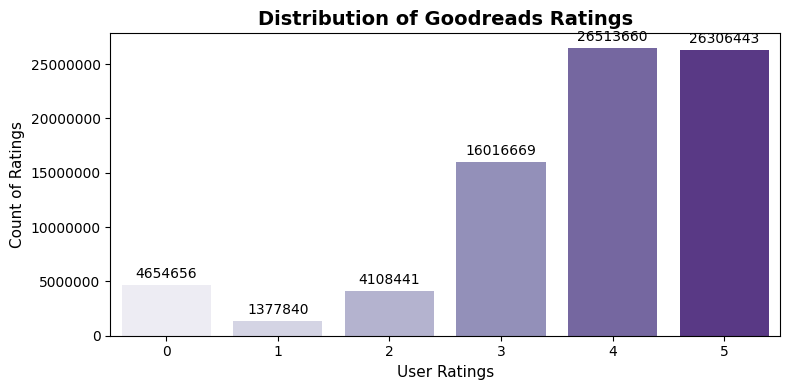

In [52]:
# takes around 1min 30secs
plt.figure(figsize=(8, 4))

ax = sns.countplot(data=user_df, 
                   x="rating", 
                   order=sorted(user_df["rating"].dropna().unique()),
                   palette="Purples")

ax.set_title("Distribution of Goodreads Ratings", fontsize=14, fontweight="bold")
ax.set_xlabel("User Ratings", fontsize=11)
ax.set_ylabel("Count of Ratings", fontsize=11)
ax.ticklabel_format(style="plain", axis="y")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [53]:
user_df['rating'].describe()

count   78,977,709.00
mean             3.74
std              1.33
min              0.00
25%              3.00
50%              4.00
75%              5.00
max              5.00
Name: rating, dtype: float64

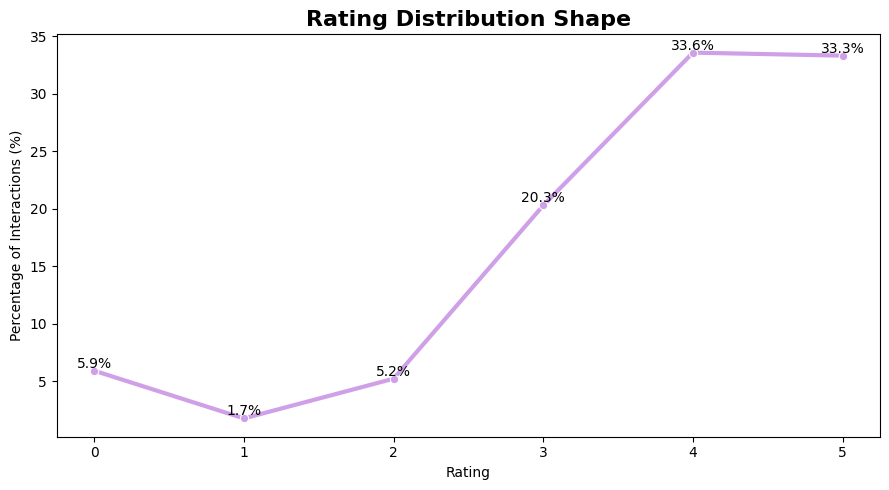

In [54]:
rating_dist = (
    user_df["rating"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .reset_index()
)

rating_dist.columns = ["rating", "percentage"]

plt.figure(figsize=(9, 5))

ax = sns.lineplot(
    data=rating_dist,
    x="rating",
    y="percentage",
    marker="o",
    linewidth=3,
    color="#CFA0E8"
)

ax.set_title("Rating Distribution Shape", fontsize=16, fontweight="bold")
ax.set_xlabel("Rating")
ax.set_ylabel("Percentage of Interactions (%)")
ax.set_xticks(sorted(user_df["rating"].dropna().unique()))

for _, row in rating_dist.iterrows():
    ax.text(
        row["rating"],
        row["percentage"],
        f'{row["percentage"]:.1f}%',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [55]:
# Rating distribution
print("\nRating distribution:")
display(
    user_df["rating"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)



Rating distribution:


,rating,count
0,0,4654656
1,1,1377840
2,2,4108441
3,3,16016669
4,4,26513660
5,5,26306443


In [56]:
print(f"Average rating: {user_df['rating'].mean():.3f}")
print(f"Median rating: {user_df['rating'].median():.3f}")

Average rating: 3.738
Median rating: 4.000


### Note

- 50% of the data has a rating greater than 4.
- Ratings are integers only.
- Ratings are negatively skewed.

In [57]:
# Number of books each user rated/read
books_per_user = (
    user_df
    .groupby("user_id")["work_id"]
    .nunique()
    .rename("num_books_rated")
)

print("\nBooks per user stats:")
display(books_per_user.describe())

print(f"Average books per user: {books_per_user.mean():.2f}")
print(f"Median books per user: {books_per_user.median():.2f}")


Books per user stats:


count   785,201.00
mean         81.76
std         161.79
min           1.00
25%          11.00
50%          32.00
75%          87.00
max      18,361.00
Name: num_books_rated, dtype: float64

Average books per user: 81.76
Median books per user: 32.00


In [58]:
user_activity = (
    user_df
    .groupby("user_id")
    .agg(
        num_books_rated=("work_id", "nunique"),
        total_interactions=("work_id", "size"),
        avg_rating=("rating", "mean"),
        median_rating=("rating", "median"),
        min_rating=("rating", "min"),
        max_rating=("rating", "max"),
    )
    .reset_index()
    .sort_values("num_books_rated", ascending=False)
)

In [59]:
bins = [0, 5, 10, 25, 50, 100, 250, 500, 1000, 2000, 5000, float("inf")]
labels = [
    "1-5",
    "6-10",
    "11-25",
    "26-50",
    "51-100",
    "101-250",
    "251-500",
    "501-1000",
    "1001-2000",
    "2001-5000",
    "5000+"
]

user_activity["activity_bucket"] = pd.cut(
    user_activity["num_books_rated"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

bucket_dist = (
    user_activity["activity_bucket"]
    .value_counts()
    .sort_index()
    .reset_index()
)

bucket_dist.columns = ["activity_bucket", "num_users"]
bucket_dist["percentage"] = bucket_dist["num_users"] / len(user_activity) * 100

display(bucket_dist)

,activity_bucket,num_users,percentage
0,1-5,122135,15.55
1,6-10,65340,8.32
2,11-25,156430,19.92
3,26-50,140915,17.95
4,51-100,129438,16.48
5,101-250,114032,14.52
6,251-500,39493,5.03
7,501-1000,13785,1.76
8,1001-2000,3112,0.40
9,2001-5000,500,0.06


### Checking for duplicates in user_df

In [68]:
user_df.shape

(78977709, 4)

In [69]:
user_df.head()

,user_id,work_id,rating,genre
0,00000377eea48021d3002730d56aca9a,2402163,5,children
1,00000377eea48021d3002730d56aca9a,2543234,4,children
2,00000377eea48021d3002730d56aca9a,2933712,1,children
3,00000377eea48021d3002730d56aca9a,3183592,3,children
4,00004584d524ec468619e81b176cc991,1069597,4,children


In [70]:
# number of fully duplicate rows across all columns
num_duplicate_rows = user_df.duplicated().sum()

num_duplicate_rows

np.int64(0)

In [71]:
# duplicates by user-work pair
num_duplicate_user_work = user_df.duplicated(
    subset=["user_id", "work_id"]
).sum()

num_duplicate_user_work

np.int64(14778129)

In [72]:
dup_user_work = user_df[
    user_df.duplicated(subset=["user_id", "work_id"], keep=False)
].sort_values(["user_id", "work_id"])

dup_user_work.head(20)

,user_id,work_id,rating,genre
8767659,00000377eea48021d3002730d56aca9a,2267189,3,fantasy
65944770,00000377eea48021d3002730d56aca9a,2267189,3,young
2,00000377eea48021d3002730d56aca9a,2933712,1,children
8767663,00000377eea48021d3002730d56aca9a,2933712,1,fantasy
8767664,00000377eea48021d3002730d56aca9a,2960529,0,fantasy
65944773,00000377eea48021d3002730d56aca9a,2960529,0,young
8767666,00000377eea48021d3002730d56aca9a,3443248,5,fantasy
65944775,00000377eea48021d3002730d56aca9a,3443248,5,young
30835171,00000377eea48021d3002730d56aca9a,10870318,5,history
65944756,00000377eea48021d3002730d56aca9a,10870318,5,young


In [73]:
# keep only the columns you want to bring into user_df
book_lookup = book_df[[
    "work_id",
    "clean_title",
    "author_ids",
    "average_rating",
    "ratings_count",
    "source_file"
]].drop_duplicates(subset=["work_id"])

user_with_titles = user_df.merge(
    book_lookup,
    on="work_id",
    how="left"
)

user_with_titles.head()

,user_id,work_id,rating,genre,clean_title,author_ids,average_rating,ratings_count,source_file
0,00000377eea48021d3002730d56aca9a,2402163,5,children,Harry Potter and the Prisoner of Azkaban,"['1077326', '2927']",4.53,1876252,children
1,00000377eea48021d3002730d56aca9a,2543234,4,children,The Giver,"['2493', '298643']",4.12,1311422,children
2,00000377eea48021d3002730d56aca9a,2933712,1,children,Alice in Wonderland,"['34933', '28120', '8164']",4.03,346530,children
3,00000377eea48021d3002730d56aca9a,3183592,3,children,The Jungle Books,"['6989', '646855', '6222648']",4.01,69923,children
4,00004584d524ec468619e81b176cc991,1069597,4,children,The Bad Beginning,['36746'],3.90,281697,children


In [75]:
dup_user_work = user_with_titles[
    user_with_titles.duplicated(subset=["user_id", "work_id"], keep=False)
].sort_values(["user_id", "work_id"])

dup_user_work.head(20)

,user_id,work_id,rating,genre,clean_title,author_ids,average_rating,ratings_count,source_file
8767659,00000377eea48021d3002730d56aca9a,2267189,3,fantasy,City of Bones,['150038'],4.12,1181693,fantasy
65944770,00000377eea48021d3002730d56aca9a,2267189,3,young,City of Bones,['150038'],4.12,1181693,fantasy
2,00000377eea48021d3002730d56aca9a,2933712,1,children,Alice in Wonderland,"['34933', '28120', '8164']",4.03,346530,children
8767663,00000377eea48021d3002730d56aca9a,2933712,1,fantasy,Alice in Wonderland,"['34933', '28120', '8164']",4.03,346530,children
8767664,00000377eea48021d3002730d56aca9a,2960529,0,fantasy,Breaking Dawn,['941441'],3.70,1078310,fantasy
65944773,00000377eea48021d3002730d56aca9a,2960529,0,young,Breaking Dawn,['941441'],3.70,1078310,fantasy
8767666,00000377eea48021d3002730d56aca9a,3443248,5,fantasy,City of Glass,['150038'],4.34,606729,fantasy
65944775,00000377eea48021d3002730d56aca9a,3443248,5,young,City of Glass,['150038'],4.34,606729,fantasy
30835171,00000377eea48021d3002730d56aca9a,10870318,5,history,Between Shades of Gray,['3407448'],4.36,90890,history
65944756,00000377eea48021d3002730d56aca9a,10870318,5,young,Between Shades of Gray,['3407448'],4.36,90890,history


In [77]:
user_df_new = user_df.drop_duplicates(
    subset=["user_id", "work_id"],
    keep="first"
).reset_index(drop=True)

print(user_df.shape)
print(user_df_new.shape)

(78977709, 4)
(64199580, 4)


In [78]:
user_df_new.head()

,user_id,work_id,rating,genre
0,00000377eea48021d3002730d56aca9a,2402163,5,children
1,00000377eea48021d3002730d56aca9a,2543234,4,children
2,00000377eea48021d3002730d56aca9a,2933712,1,children
3,00000377eea48021d3002730d56aca9a,3183592,3,children
4,00004584d524ec468619e81b176cc991,1069597,4,children


In [79]:
user_df = user_df_new.copy()

/var/folders/hv/ssw7w9251n33ldwz20jqx8qw0000gn/T/ipykernel_679/2046324548.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=user_df,


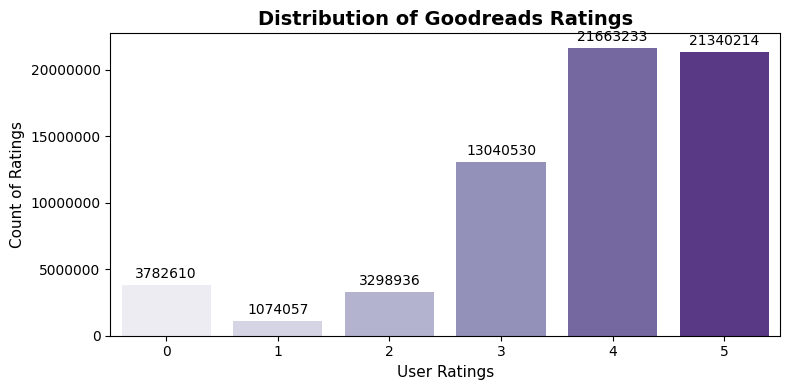

In [80]:
# takes around 1min 30secs
plt.figure(figsize=(8, 4))

ax = sns.countplot(data=user_df, 
                   x="rating", 
                   order=sorted(user_df["rating"].dropna().unique()),
                   palette="Purples")

ax.set_title("Distribution of Goodreads Ratings", fontsize=14, fontweight="bold")
ax.set_xlabel("User Ratings", fontsize=11)
ax.set_ylabel("Count of Ratings", fontsize=11)
ax.ticklabel_format(style="plain", axis="y")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

In [81]:
# Number of users per book
users_per_book = (
    user_df
    .groupby("work_id")["user_id"]
    .nunique()
    .rename("num_users_rated")
)

print("\nUsers per book stats:")
display(users_per_book.describe())

print(f"Average users per book: {users_per_book.mean():.2f}")
print(f"Median users per book: {users_per_book.median():.2f}")


Users per book stats:


count   451,538.00
mean        142.18
std       1,785.61
min           1.00
25%           5.00
50%          14.00
75%          45.00
max     304,536.00
Name: num_users_rated, dtype: float64

Average users per book: 142.18
Median users per book: 14.00


In [82]:
# Number of books each user rated/read
books_per_user = (
    user_df
    .groupby("user_id")["work_id"]
    .nunique()
    .rename("num_books_rated")
)

print("\nBooks per user stats:")
display(books_per_user.describe())

print(f"Average books per user: {books_per_user.mean():.2f}")
print(f"Median books per user: {books_per_user.median():.2f}")


Books per user stats:


count   785,201.00
mean         81.76
std         161.79
min           1.00
25%          11.00
50%          32.00
75%          87.00
max      18,361.00
Name: num_books_rated, dtype: float64

Average books per user: 81.76
Median books per user: 32.00


In [83]:
user_df.head()

,user_id,work_id,rating,genre
0,00000377eea48021d3002730d56aca9a,2402163,5,children
1,00000377eea48021d3002730d56aca9a,2543234,4,children
2,00000377eea48021d3002730d56aca9a,2933712,1,children
3,00000377eea48021d3002730d56aca9a,3183592,3,children
4,00004584d524ec468619e81b176cc991,1069597,4,children


In [84]:
user_with_titles.head()

,user_id,work_id,rating,genre,clean_title,author_ids,average_rating,ratings_count,source_file
0,00000377eea48021d3002730d56aca9a,2402163,5,children,Harry Potter and the Prisoner of Azkaban,"['1077326', '2927']",4.53,1876252,children
1,00000377eea48021d3002730d56aca9a,2543234,4,children,The Giver,"['2493', '298643']",4.12,1311422,children
2,00000377eea48021d3002730d56aca9a,2933712,1,children,Alice in Wonderland,"['34933', '28120', '8164']",4.03,346530,children
3,00000377eea48021d3002730d56aca9a,3183592,3,children,The Jungle Books,"['6989', '646855', '6222648']",4.01,69923,children
4,00004584d524ec468619e81b176cc991,1069597,4,children,The Bad Beginning,['36746'],3.90,281697,children


In [85]:
user_df = user_df.merge(
    book_df[["work_id", "clean_title"]].drop_duplicates(subset=["work_id"]),
    on="work_id",
    how="left"
)

user_df.head()

,user_id,work_id,rating,genre,clean_title
0,00000377eea48021d3002730d56aca9a,2402163,5,children,Harry Potter and the Prisoner of Azkaban
1,00000377eea48021d3002730d56aca9a,2543234,4,children,The Giver
2,00000377eea48021d3002730d56aca9a,2933712,1,children,Alice in Wonderland
3,00000377eea48021d3002730d56aca9a,3183592,3,children,The Jungle Books
4,00004584d524ec468619e81b176cc991,1069597,4,children,The Bad Beginning


In [88]:
user_df.to_csv('../data/final-user.csv', index=False)